In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/maimunarahma/ai-ml/main/kMeans/datasets/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
!git clone https://github.com/maimunarahma/ai-ml

Cloning into 'ai-ml'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 86 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 1.82 MiB | 4.84 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [4]:
import pandas as pd

custom_data = pd.read_csv(
    "/content/ai-ml/kMeans/datasets/custom.csv"
)
custom_data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,81
1,22,18,77
2,25,25,60
3,28,40,65
4,32,50,45


In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [9]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [10]:
custom_scaled = scaler.transform(custom_data)

In [11]:
clusters = kmeans.predict(custom_scaled)

In [12]:
main_clusters = kmeans.predict(X_scaled)

In [13]:
custom_data["Cluster"] = clusters


In [25]:
# Show table
print(custom_data)

   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   19                  15                      81        2
1   22                  18                      77        2
2   25                  25                      60        2
3   28                  40                      65        2
4   32                  50                      45        3
5   35                  60                      40        3
6   40                  70                      30        4
7   45                  85                      20        4
8   50                  95                      15        4
9   27                  35                      75        2


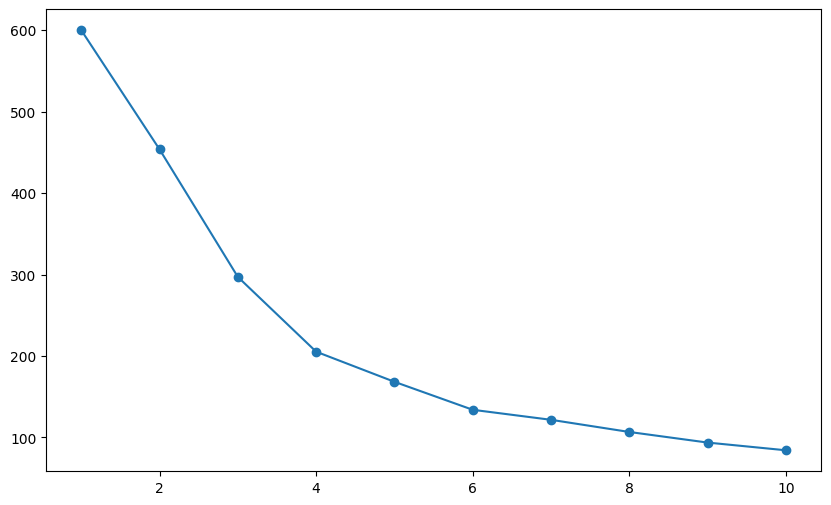

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1,11), wcss, marker='o')

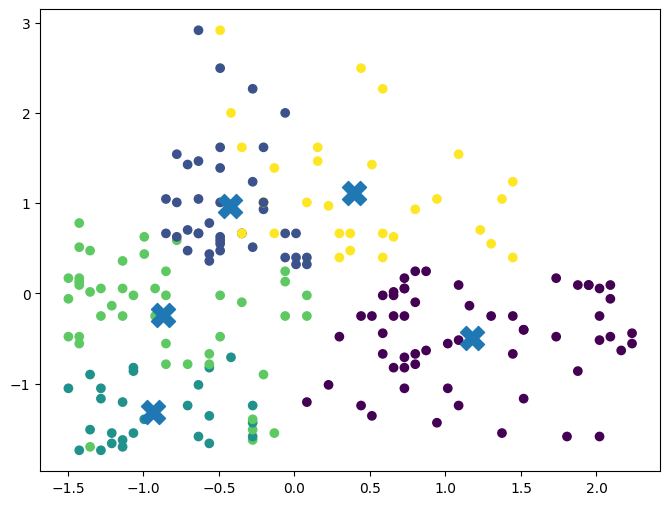

In [24]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    marker='X'
)

plt.show()

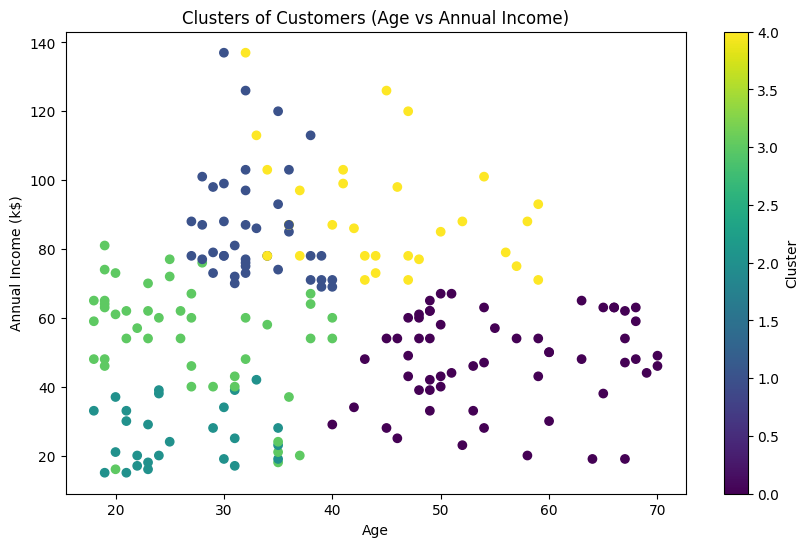

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=main_clusters)
plt.title('Clusters of Customers (Age vs Annual Income)')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.colorbar(label='Cluster')
plt.show()

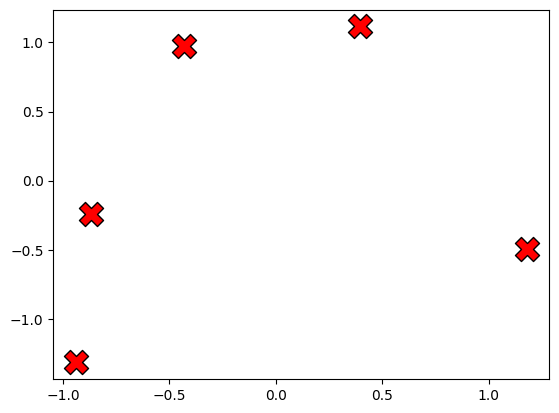

In [26]:
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    color='red',
    edgecolor='black'
)

In [27]:
# ==============================
# CLUSTER INTERPRETATION
# ==============================

centroids = kmeans.cluster_centers_

for i, centroid in enumerate(centroids):
    print(f"Cluster {i}:")

    print(f"- Average feature values: {centroid}")

    print("Interpretation:")

    # Example interpretation logic (customize based on your dataset)
    if centroid[0] > 0 and centroid[1] > 0:
        print("This cluster represents high values in both features, indicating premium/high-level group.\n")

    elif centroid[0] < 0 and centroid[1] < 0:
        print("This cluster represents low values in both features, indicating low activity or low-level group.\n")

    else:
        print("This cluster represents moderate or mixed behavior across features.\n")

Cluster 0:
- Average feature values: [ 1.17882975 -0.49388609 -0.32971553]
Interpretation:
This cluster represents moderate or mixed behavior across features.

Cluster 1:
- Average feature values: [-0.42880597  0.97484722  1.21608539]
Interpretation:
This cluster represents moderate or mixed behavior across features.

Cluster 2:
- Average feature values: [-0.93876351 -1.31473131  0.95680216]
Interpretation:
This cluster represents low values in both features, indicating low activity or low-level group.

Cluster 3:
- Average feature values: [-0.86957306 -0.23851652 -0.36060916]
Interpretation:
This cluster represents low values in both features, indicating low activity or low-level group.

Cluster 4:
- Average feature values: [ 0.39737911  1.11508909 -1.23126963]
Interpretation:
This cluster represents high values in both features, indicating premium/high-level group.

